In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('..')
from src.data_loader import fetch_stock_data

# AMZN verisini indir
df = fetch_stock_data('AMZN', '2015-01-01', '2025-01-01', save_path='data/raw/AMZN_2015-2025.csv')

📥 AMZN verisi indiriliyor (2015-01-01 - 2025-01-01)...


[*********************100%***********************]  1 of 1 completed

✅ 2516 satır veri hazır.
💾 Kaydedildi: data/raw/AMZN_2015-2025.csv


In [2]:
# Veri keşfi
print('Veri Bilgisi:')
df.info()
print('\nİstatistikler:')
df.describe()
print('\nİlk 5 Satır:')
df.head()
print('\nEksik Veri:')
df.isnull().sum()

Veri Bilgisi:
<class 'pandas.DataFrame'>
DatetimeIndex: 2516 entries, 2015-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2516 non-null   float64
 1   High    2516 non-null   float64
 2   Low     2516 non-null   float64
 3   Open    2516 non-null   float64
 4   Volume  2516 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 117.9 KB

İstatistikler:

İlk 5 Satır:

Eksik Veri:


Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

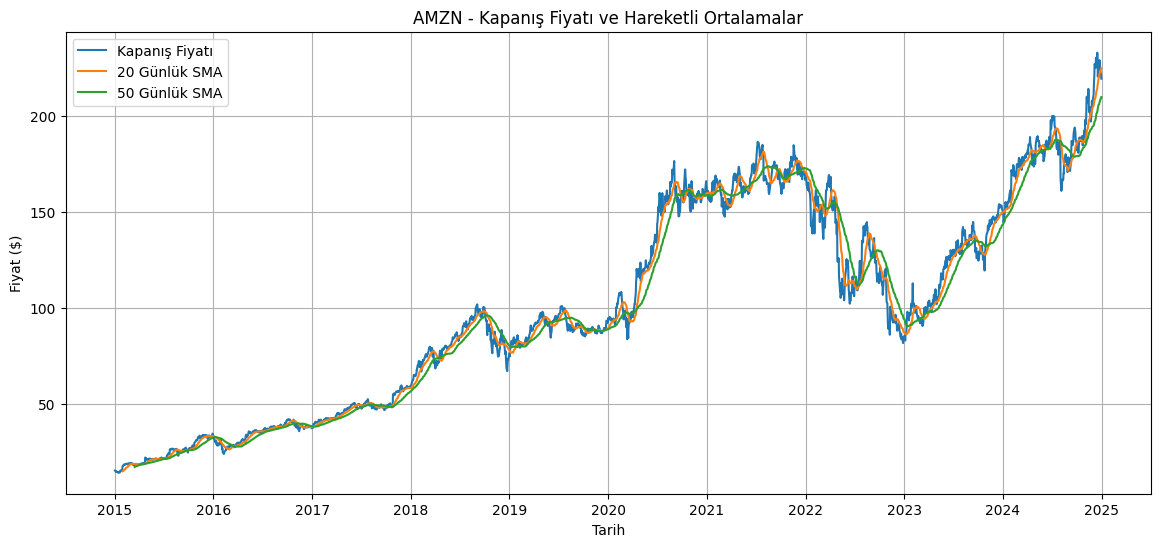

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Kapanış Fiyatı ve Hareketli Ortalamalar
plt.figure(figsize=(14, 6))
plt.plot(df['Close'], label='Kapanış Fiyatı')
plt.plot(df['Close'].rolling(window=20).mean(), label='20 Günlük SMA')
plt.plot(df['Close'].rolling(window=50).mean(), label='50 Günlük SMA')
plt.title('AMZN - Kapanış Fiyatı ve Hareketli Ortalamalar')
plt.xlabel('Tarih')
plt.ylabel('Fiyat ($)')
plt.legend()
plt.grid(True)
plt.show()

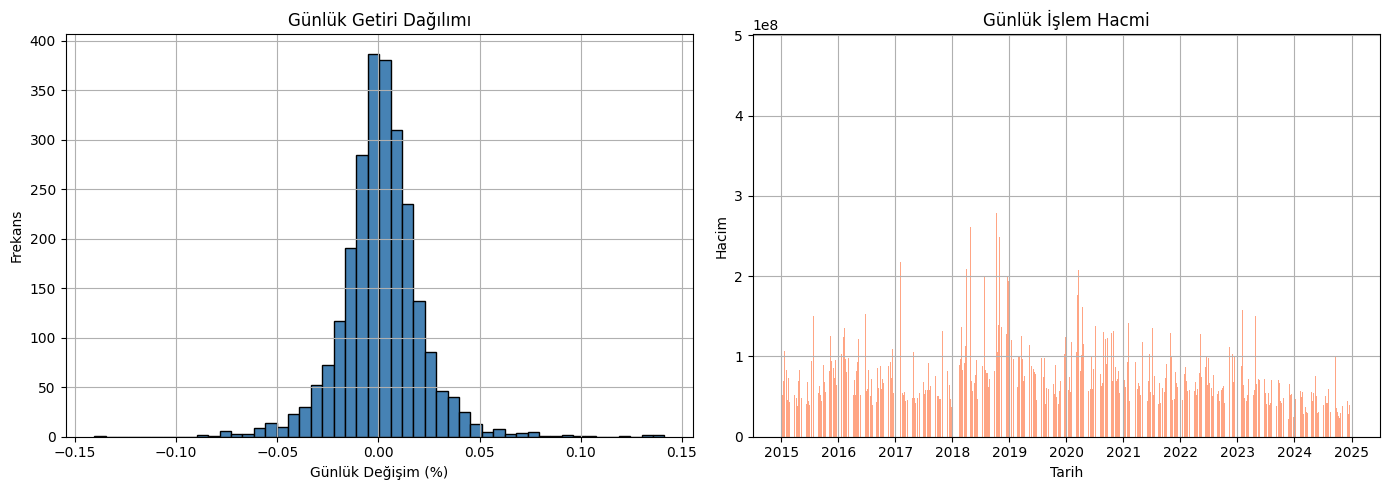

In [4]:
# Getiri Dağılımı
daily_returns = df['Close'].pct_change().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(daily_returns, bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Günlük Getiri Dağılımı')
axes[0].set_xlabel('Günlük Değişim (%)')
axes[0].set_ylabel('Frekans')
axes[0].grid(True)

# Hacim Grafiği
axes[1].bar(df.index, df['Volume'], color='coral', alpha=0.7)
axes[1].set_title('Günlük İşlem Hacmi')
axes[1].set_xlabel('Tarih')
axes[1].set_ylabel('Hacim')
axes[1].grid(True)

plt.tight_layout()
plt.show()